In [1]:
from functools import partial

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn.objects as so
import pywt
import anisotropy
from common import sweep, normalize


def generate_true(*, total_intensity, size):
    ani = pywt.data.demo_signal("blocks", size)
    ani = 0.1 + 0.8 * normalize(ani)
    images = anisotropy.intensity_from_anisotropy(ani, total_intensity)
    return images

In [2]:
size = 2**10

rng = np.random.default_rng(42)

df = []
N0 = 30
for N in (0, 100, 500):
    x_true = generate_true(
        total_intensity=np.random.default_rng(42).uniform(N0, N0+N, size=size),
        size=size,
    )
    for linear in (False,):
        df.append(
            sweep(
                sigmas=np.linspace(0, 5, 20),
                x_true=anisotropy.anisotropy(x_true),
                x_var_true=anisotropy.anisotropy_variance(x_true),
                measure_func=lambda x: rng.poisson(x_true),
                value_func=anisotropy.anisotropy,
                binlets_funcs={
                    "Independent": partial(anisotropy.independent_binlets, linear=linear),
                    "Joint": partial(anisotropy.joint_poisson_binlets, linear=linear),
                    "Anisotropy": partial(anisotropy.joint_binlets, linear=linear),
                    # "Anisotropy2": partial(anisotropy.anisotropy_binlets, linear=linear),
                },
                repeats=10,
            ).assign(N=N)
    )
df = pd.concat(df)

In [3]:
improvement = (
    1
    / df.groupby(["sigma", "variant", "N"])
    .RMSE.mean()
    .reset_index()
    .groupby(["variant", "N"])
    .RMSE.min()
)

improvement.unstack()

N,0,100,500
variant,,,
Anisotropy,3.015345,3.803144,4.196676
Independent,2.501687,1.395710,0.989987
Joint,3.303892,2.010696,1.209154


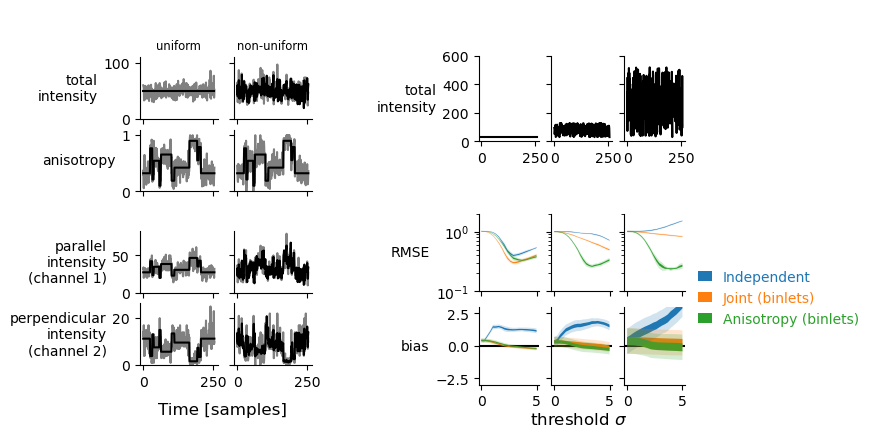

In [4]:
import plot
import seaborn


class Color:
    true = "black"
    measured = "gray"
    anisotropy = "C4"
    total = "black"


def panel_A(fig):
    size = 256
    hspace = 0.3
    axes = fig.subplots(
        5,
        2,
        sharex=True,
        sharey="row",
        height_ratios=[1, 1, hspace, 1, 1],
    )

    fig.supxlabel("Time [samples]", y=-0.02)

    for ax in axes[2]:
        ax.set_visible(False)
    axes = axes[[0, 1, -2, -1]]
    rng = np.random.default_rng(42)

    def plot_images(axes, images_true):
        images_measured = rng.poisson(images_true)

        for images, label, color in [
            (images_measured, "Measured", Color.measured),
            (images_true, "True", Color.true),
        ]:
            axes[0].plot(anisotropy.total_intensity(*images), label=label, color=color)
            axes[1].plot(anisotropy.anisotropy(images), label=label, color=color)
            axes[2].plot(images[0], label=label, color=color)
            axes[3].plot(images[1], label=label, color=color)

    plot_images(axes[:, 0], images_true=generate_true(total_intensity=50, size=size))
    plot_images(
        axes[:, 1],
        images_true=generate_true(
            total_intensity=rng.normal(50, 10, size=size), size=size
        ),
    )

    axes[0, 0].set(ylim=(0, 110))
    axes[1, 0].set(ylim=(0, 1.1))
    axes[2, 0].set(ylim=(0, None))
    axes[3, 0].set(ylim=(0, None))

    axes[0, 0].set_ylabel("total\nintensity", rotation=0, va="center", ha="right")
    axes[1, 0].set_ylabel("anisotropy", rotation=0, va="center", ha="right")
    axes[2, 0].set_ylabel("parallel\nintensity\n(channel 1)", rotation=0, va="center", ha="right")
    axes[3, 0].set_ylabel(
        "perpendicular\nintensity\n(channel 2)", rotation=0, va="center", ha="right"
    )

    axes[0,0].set_title("uniform", fontsize="small")
    axes[0,1].set_title("non-uniform", fontsize="small")
    return
    plot.legend_without_duplicate_labels(
        fig,
        labelcolor="linecolor",
        handlelength=1,
        ncols=2,
        frameon=False,
    )


def panel_B(fig):
    _, fig_top, _, fig_bottom = fig.subfigures(4, height_ratios=[0.3, 1, 0.3, 2])
    _.set_visible(False)

    N = df.N.unique()
    axes = fig_top.subplots(1, len(N), sharey=True)
    for ax, Ni in zip(axes, N):
        total_intensity = rng.uniform(N0, N0 + Ni, size=256)
        ax.plot(total_intensity, color=Color.total)
    ax.set(ylim=(0, 600))
    axes[0].set_ylabel("total\nintensity", rotation=0, va="center", ha="right")

    (
        so.Plot(df, x="sigma", color="variant")
        .pair(y=["RMSE", "bias"])
        .label(x="")
        .facet(col="N")
        .add(so.Band(alpha=1), so.Est(errorbar="se"))
        .add(so.Band(), so.Est(errorbar="sd"))
        .theme(plt.rcParams)
        .on(fig_bottom)
        .plot()
    )
    for ax in fig_bottom.axes:
        ax.set(title="")
    fig_bottom.axes[0].set(yscale="log", ylim=(0.1, 2))
    fig_bottom.axes[-1].set(ylim=(-3, 3))
    for ax in fig_bottom.axes[3:]:
        ax.axhline(0, zorder=-1, color="black")

    fig_bottom.axes[0].set_ylabel("RMSE", rotation=0, va="center", ha="right")
    fig_bottom.axes[3].set_ylabel("bias", rotation=0, va="center", ha="right")
    fig_bottom.supxlabel("threshold $\sigma$", y=-0.08)

    fig.figure.legends = []
    seaborn.despine(fig, top=True, right=True)
    fig_bottom.legend(
        ["Independent", "Joint (binlets)", "Anisotropy (binlets)"],
        bbox_to_anchor=(0.9, 0.5),
        loc="center left",
        labelcolor="linecolor",
        frameon=False,
        handlelength=1,
    )

    fig_bottom.align_ylabels()


fig = plt.figure(figsize=(6, 4), layout="constrained")
fig_left, _fig, fig_right = fig.subfigures(1, 3, width_ratios=[1, 0.5, 1.2])
_fig.set_visible(False)
panel_A(fig_left)
panel_B(fig_right)
seaborn.despine(fig)

path = "../article/figures/4_anisotropy_1D"
fig.savefig(path + ".png", bbox_inches="tight")
fig.savefig(path + ".pdf", bbox_inches="tight")